In [4]:
import sys
import os

sys.path.append(os.path.abspath("utils"))
import pandas as pd

from general_utils import plot_random_image_samples

/opt/conda/envs/rapids/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/opt/conda/envs/rapids/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [3]:
DATASET_NAME = 'Coco'

# Print Qualitative Info About Datasets

In [5]:
metadata = pd.read_csv(f'../Data/{DATASET_NAME}/metadata.csv')
print(f"Number of data samples: {len(metadata)}")
concept_cols = [col for col in metadata.columns if col not in ['image_path', 'class', 'split']]                                               
print(f"Number of distinct concepts: {len(concept_cols)}")
concept_categories = set([col.split("::")[0] for col in concept_cols])
print(f"Number of distinct concept categories: {len(concept_categories)}")

Number of data samples: 1001
Number of distinct concepts: 6
Number of distinct concept categories: 2


# Show Statistics of Positive/Negative Concepts

In [ ]:
#By Sample

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV file
df = pd.read_csv(f'../Data/{DATASET_NAME}/metadata.csv')  # Replace with your file path

# Exclude non-concept columns
excluded_columns = {"image_path", "class", "split"}
concept_columns = [col for col in df.columns if col not in excluded_columns]

# Split data into train and test sets
train_df = df[df["split"] == "train"]
test_df = df[df["split"] == "test"]

# Count occurrences of each concept
train_counts = train_df[concept_columns].sum()
test_counts = test_df[concept_columns].sum()

# Total counts across train and test
total_counts = train_counts + test_counts

# Sort concepts by total frequency (ascending)
sorted_concepts = total_counts.sort_values().index.tolist()

# Split the sorted concepts in half
mid = len(sorted_concepts) // 2
low_freq_concepts = sorted_concepts[:mid]
high_freq_concepts = sorted_concepts[mid:]

# Print or use the concept splits
print(f"Low freq concepts: {low_freq_concepts}")
print(f"High freq concepts: {high_freq_concepts}")     

Low freq concepts: ['toaster', 'hair drier', 'scissors', 'toothbrush', 'parking meter', 'bear', 'snowboard', 'hot dog', 'microwave', 'donut', 'sheep', 'stop sign', 'broccoli', 'apple', 'carrot', 'frisbee', 'orange', 'zebra', 'fire hydrant', 'cow', 'mouse', 'elephant', 'kite', 'teddy bear', 'airplane', 'baseball bat', 'sandwich', 'baseball glove', 'giraffe', 'refrigerator', 'banana', 'suitcase', 'keyboard', 'wine glass', 'oven', 'skis', 'boat', 'cake', 'bird', 'skateboard', 'horse', 'vase', 'tie', 'remote', 'toilet']
High freq concepts: ['bed', 'surfboard', 'bicycle', 'spoon', 'pizza', 'fork', 'train', 'motorcycle', 'tennis racket', 'sports ball', 'potted plant', 'umbrella', 'dog', 'knife', 'laptop', 'cat', 'sink', 'bus', 'traffic light', 'couch', 'clock', 'tv', 'cell phone', 'backpack', 'book', 'bench', 'truck', 'handbag', 'bowl', 'appliance', 'bottle', 'cup', 'dining table', 'car', 'outdoor', 'chair', 'electronic', 'indoor', 'food', 'accessory', 'kitchen', 'sports', 'animal', 'vehicle

206.21978021978023


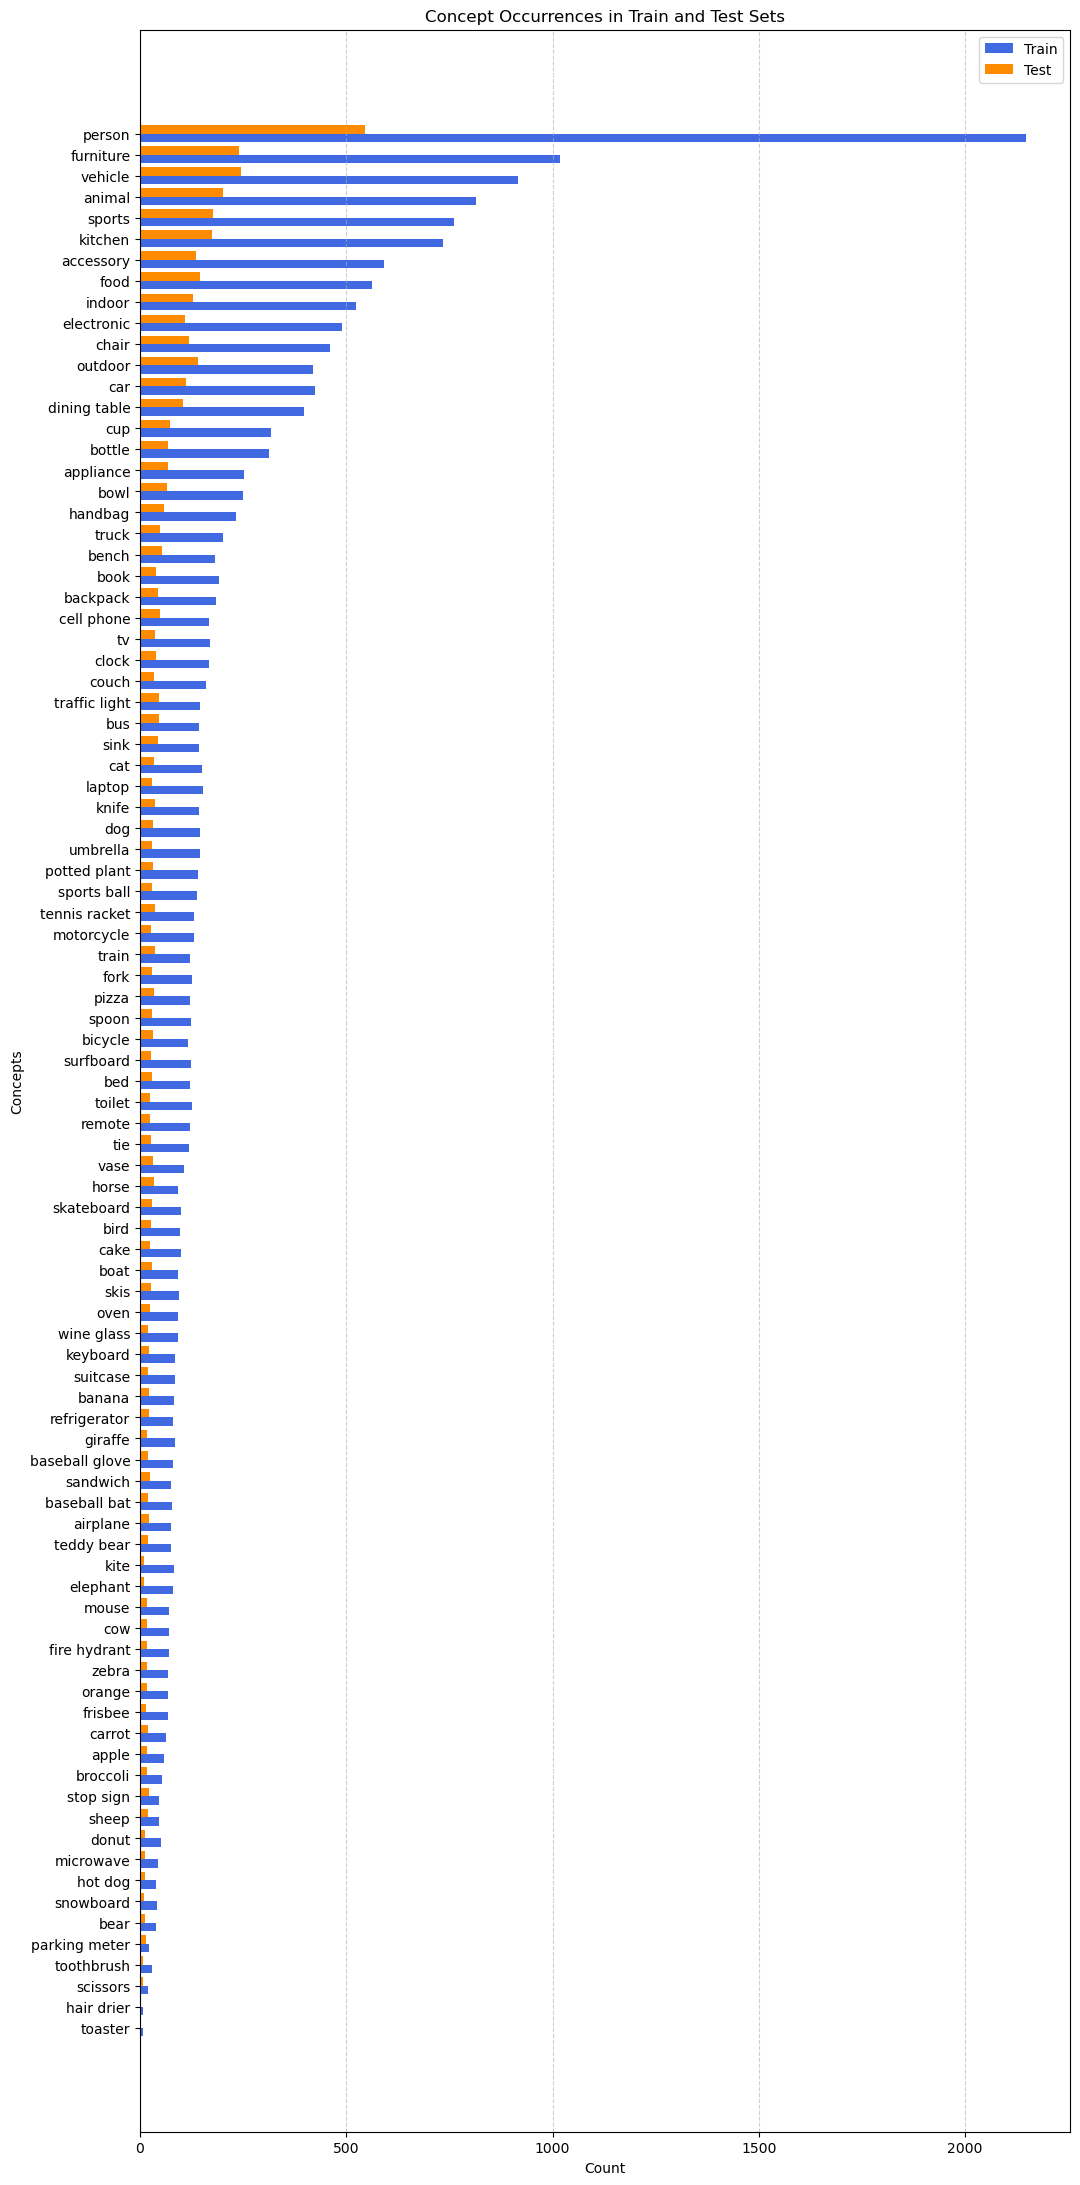

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV file
df = pd.read_csv(f'../Data/{DATASET_NAME}/metadata.csv')  # Replace with your file path

# Exclude non-concept columns
excluded_columns = {"image_path", "class", "split"}
concept_columns = [col for col in df.columns if col not in excluded_columns]

# Split data into train and test sets
train_df = df[df["split"] == "train"]
test_df = df[df["split"] == "test"]

# Count occurrences of each concept
train_counts = train_df[concept_columns].sum()
test_counts = test_df[concept_columns].sum()

# Sort concepts by total occurrences (train + test) for better visualization
sorted_indices = (train_counts + test_counts).sort_values().index
train_counts = train_counts[sorted_indices]
test_counts = test_counts[sorted_indices]

# Set up bar positions
y_pos = np.arange(len(concept_columns))
bar_width = 0.4  # Width of each bar

# Create figure
plt.figure(figsize=(12, len(concept_columns) * 0.3))

# Plot bars
plt.barh(y_pos - bar_width / 2, train_counts, height=bar_width, label="Train", color="royalblue")
plt.barh(y_pos + bar_width / 2, test_counts, height=bar_width, label="Test", color="darkorange")

# Labels and title
plt.xlabel("Count")
plt.ylabel("Concepts")
plt.title("Concept Occurrences in Train and Test Sets")
plt.yticks(y_pos, sorted_indices)
plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.6)

# Show plot
plt.show()


In [ ]:
#By Patch

# Example of Samples from a Dataset

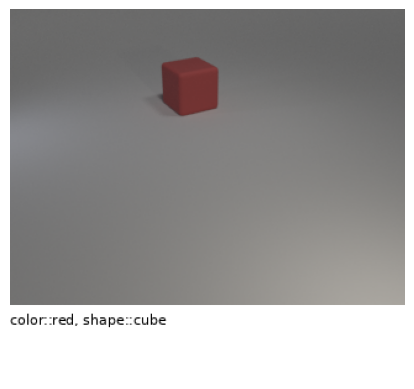

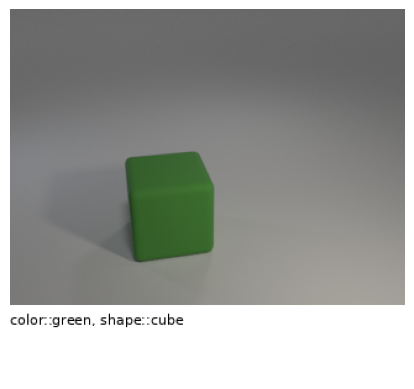

In [3]:
plot_random_image_samples(num_samples=2)